## 자연어와 단어의 분산 표현

### 자연어 처리란
* 자연어: 평소에 쓰는 말
* 자연어 처리(NLP): 자연어를 처리하는 분야, 우리의 말을 컴퓨터에게 이해시키기 위한 기술

#### 단어의 의미
* 말은 문자로 구성, 말의 의미는 단어로 구성
* 컴퓨터에게 단어의 의미를 이해시키는 것이 중요함
    * 시소러스(유의어 사전)를 활용한 기법
    * 통계 기반 기법
    * 추론 기반 기법(word2vec)

### 시소러스
* 유의어 사전으로, 동의어나 유의어가 한 그룹으로 분류되어 있음
* 예시
    * car = auto, automobile, machine, motorcar
* 시소러스에서는 단어 사이의 상위와 하위 또는 전체와 부분 등 세세한 관계까지 정의해둔 경우가 있음
* 모든 단어에 대한 유의어 집합을 만든 다음, 단어들의 관계를 그래프로 표현하여 단어 사이의 연결을 정의할 수 있음
* 이를 이용해 컴퓨터에게 단어 사이의 관계를 가르칠 수 있음  
    => 간접적으로라도 컴퓨터에게 단어의 의미를 이해시켰음
* 시소러스를 어떻게 사용하는가는 자연어 처리 애플리케이션에 따라 다름

#### WordNet
* 자연어 처리 분야에서 가장 유명한 시소러스
* 프린스턴 대학교에서 1985년부터 구축하기 시작한 전통 있는 시소러스, 다양한 자연어 처리 애플리케이션에서 활용
* WordNet 사용 시 유의어를 얻거나 단어 네트워크 이용 가능, 단어 사이의 유사도를 구하는 것도 가능

#### 시소러스의 문제점
* 시대 변화에 대응하기 어려움
* 사람을 쓰는 비용이 큼
* 단어의 미묘한 차이를 표현할 수 없음  
=> 사람의 개입을 최소로 줄이고 텍스트 데이터만으로 원하는 결과를 얻어내는 방향으로 패러다임이 바뀜

### 통계 기반 기법
* 말뭉치(corpus)를 이용
    * 말뭉치: 대량의 텍스트 데이터
    * 단, 맹목적으로 수집된 텍스트 데이터가 아닌 연구나 애플리케이션을 염두에 두고 수집된 텍스트
* 통계 기반 기법의 목표는 사람의 지식으로 가득한 말뭉치에서 자동으로, 효율적으로 핵심을 추출하는 것
* 텍스트의 데이터의 단어 각각에 품사가 레이블링될 수 있음
* 말뭉치는 컴퓨터가 다루기 쉬운 트리 형태 등으로 가공되어 주어지는 것이 일반적

#### 파이썬으로 말뭉치 전처리하기

In [6]:
text = "You say goodbye and I say hello."

text = text.lower()
text = text.replace('.', ' .')
print(text)

words = text.split()
print(words)

you say goodbye and i say hello .
['you', 'say', 'goodbye', 'and', 'i', 'say', 'hello', '.']


* 단어 단위로 분할되어 다루기는 쉬워짐
* 단어를 텍스트 그대로 조작하긴 어려움  
=> 단어에 ID를 부여, ID의 리스트로 이용할 수 있도록

In [7]:
word_to_id = {}
id_to_word = {}

for word in words:
    if word not in word_to_id:
        new_id = len(word_to_id)
        word_to_id[word] = new_id
        id_to_word[new_id] = word

print(id_to_word)
print(word_to_id)

{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}
{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}


In [8]:
# 파이썬의 comprehension 표기를 사용 -> 단어 ID 목록 -> 넘파이 배열
import numpy as np
corpus = [word_to_id[w] for w in words]
corpus = np.array(corpus)
print(corpus)

[0 1 2 3 4 1 5 6]


In [ ]:
def preprocess(text):
    text = text.lower()
    text = text.replace('.', ' .')
    words = text.split()

    word_to_id = {}
    id_to_word = {}

    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word

    corpus = np.array([word_to_id[w] for w in words])

    return corpus, word_to_id, id_to_word

In [ ]:
text = "You say goodbye and I say hello"
corpus, word_to_id, id_to_word = preprocess(text)

print(corpus)
print(word_to_id)
print(id_to_word)

[0 1 2 3 4 1 5]
{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5}
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello'}


* 말뭉치 준비 완료!

#### 단어의 분산 표현
* 분산 표현: 단어의 의미를 정확하게 파악할 수 있는 벡터 표현
    * 단어의 분산 표현은 단어를 고정 길이의 밀집벡터로 표현
    * 밀집벡터: 대부분 원소가 0이 아닌 실수인 벡터
    * 3차원의 분산 벡터는 [0.21, -0.45, 0.83] 같이 표현

#### 분포 가설
* 분포 가설: 단어의 의미는 주변 단어에 의해 형성됨
* 단어 자체에는 의미가 없고, 그 단어가 사용된 맥락이 의미를 형성
* 맥락: 특정 단어를 중심에 둔 그 주변 단어
* 윈도우 크기: 맥락의 크기(주변 단어를 몇 개나 포함할지)

#### 동시발생 행렬
* 분포 가설에 기초해 단어를 벡터로 나타내는 방법  
=> 어떤 단어에 주목했을 때, 주변에 어떤 단어가 몇 번이나 등장하는지를 세어 집계하는 방법

In [ ]:
import sys
sys.path.append('..')
import numpy as np
from common.util import preprocess

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


* 윈도우 크기를 1, 단어 ID를 0부터 맥락에 해당하는 단어의 빈도를 세면
    * you: [0, 1, 0, 0, 0, 0, 0]
    * say: [1, 0, 1, 0, 1, 1, 0]   
    ...
    * 모든 단어에 대해 동시발생하는 단어를 표로 정리하면 행렬의 형태를 띄며 이를 동시발생 행렬이라 함

In [ ]:
C = np.array([
    [0, 1, 0, 0, 0, 0, 0], 
    [1, 0, 1, 0, 1, 1, 0], 
    [0, 1, 0, 1, 0, 0, 0], 
    [0, 0, 1, 0, 1, 0, 0], 
    [0, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 1], 
    [0, 0, 0, 0, 0, 1, 0]])

print(C[0]) # ID: 0
print(C[4]) # ID: 4
print(C[word_to_id["goodbye"]]) # goodbye의 벡터 표현

[0 1 0 0 0 0 0]
[0 1 0 1 0 0 0]
[0 1 0 1 0 0 0]


* 단어를 벡터로 나타낼 수 있음

In [ ]:
def create_co_matrix(corpus, vocab_size, window_size=1):
    corpus_size = len(corpus)
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int)

    for idx, word_id in enumerate(corpus):
        for i in range(1, window_size + 1):
            left_idx = idx - i
            right_idx = idx + i

            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word_id, left_word_id] += 1
            
            if right_idx < corpus_size:
                right_word_id = corpus[right_idx]
                co_matrix[word_id, right_word_id] += 1
    
    return co_matrix

### 벡터 간 유사도
* 벡터 간 유사도 측정 방법: 벡터의 내적, 유클리드 거리 등
* 코사인 유사도를 자주 사용
$$
\text{similarity}(x, y)
= \frac{x \cdot y}{\|x\| \|y\|}
= \frac{\sum_{i=1}^{n} x_i y_i}
{\sqrt{\sum_{i=1}^{n} x_i^2} \; \sqrt{\sum_{i=1}^{n} y_i^2}}
$$

* 분자는 벡터의 내적, 분모는 각 벡터의 노름
* 노름: 벡터의 크기를 계산, 여기서는 L2 노름  
    * L2 노름: 벡터의 각 원소를 제곱해 더한 후 다시 제곱근을 구해 계산  
=> 벡터를 정규화하고 내적을 구하는 것

In [ ]:
def cos_similarity(x, y):
    nx = x / np.sqrt(np.sum(x ** 2))
    ny = y / np.sqrt(np.sum(y ** 2))

    return np.dot(nx, ny)

* 이 구현은 divide by zero 오류가 발생할 수 있음

In [ ]:
def cos_similarity(x, y, eps=1e-8):
    nx = x / np.sqrt(np.sum(x ** 2) + eps)
    ny = y / np.sqrt(np.sum(y ** 2) + eps)

    return np.dot(nx, ny)

In [ ]:
import sys
sys.path.append("..")
from common.util import preprocess, create_co_matrix, cos_similarity

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)

c0 = C[word_to_id["you"]]
c1 = C[word_to_id["i"]]
print(cos_similarity(c0, c1))

0.7071067691154799


* 코사인 유사도 값은 -1~1 사이이므로 0.707은 비교적 높음

#### 유사 단어의 랭킹 표시
* 어떤 단어가 검색어로 주어지면, 그 검색어와 비슷한 단어를 유사도 순으로 출력하는 함수

In [ ]:
def most_similar(query, word_to_id, id_to_word, word_matrix, top=5):
    # 검색어를 꺼냄
    if query not in word_to_id:
        print('%s(을)를 찾을 수 없습니다.' % query)
        return

    print('\n[query] ' + query)
    query_id = word_to_id[query]
    query_vec = word_matrix[query_id]

    # 코사인 유사도 계산
    vocab_size = len(id_to_word)

    similarity = np.zeros(vocab_size)
    for i in range(vocab_size):
        similarity[i] = cos_similarity(word_matrix[i], query_vec)

    # 코사인 유사도를 기준으로 내림차순으로 출력
    count = 0
    for i in (-1 * similarity).argsort():
        if id_to_word[i] == query:
            continue
        print(' %s: %s' % (id_to_word[i], similarity[i]))

        count += 1
        if count >= top:
            return

In [ ]:
# 넘파이 배열의 원소를 오름차순으로 정렬, 반환값은 배열의 인덱스
x = np.array([100, -20, 2])
print(x.argsort())

[1 2 0]


In [ ]:
# you를 검색어로 지정해 가장 유사한 단어들을 출력
import sys
sys.path.append('..')
from common.util import preprocess, create_co_matrix, most_similar

text = "You say goodbye and I say hello"
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)

most_similar("you", word_to_id, id_to_word, C, top=5)


[query] you
 hello: 0.9999999800000005
 i: 0.7071067691154799
 goodbye: 0.7071067691154799
 and: 0.0
 say: 0.0


* 말뭉치의 크기가 너무 작아서 납득이 어려움

### 통계 기반 기법 개선하기

#### 상호정보량
* 동시발생 행렬의 원소는 두 단어가 동시에 발생한 횟수를 나타냄 -> 발생 횟수는 좋은 특징이 아님  
    => 점별 상호정보량(PMI)라는 척도 사용
$$
\mathrm{PMI}(x, y) = \log \frac{P(x, y)}{P(x) P(y)}
$$
* P(x): x가 일어날 확률, 단어 x가 말뭉치에 등장할 확률
* P(x, y): 단어 x, y가 동시발생할 확률

$$
\mathrm{PMI}(x, y)
= \log \frac{P(x, y)}{P(x) P(y)}
= \log \frac{\frac{C(x, y)}{N}}{\frac{C(x)}{N} \frac{C(y)}{N}}
= \log \frac{C(x, y) \cdot N}{C(x)\, C(y)}
$$
* C: 동시발생 행렬
* C(x, y): 단어 x, y가 동시에 발생하는 횟수
* C(x), C(y): 각각 단어 x와 y의 등장 횟수
* N: 말뭉치에 포함된 단어 수

* 단어가 단독으로 출현하는 횟수를 고려
* 다만 두 단어의 동시발생 횟수가 0이면 $-\infin$ 가 됨  
=> 실제로 구현할 때는 양의 상호정보량(PPMI)를 사용
$$
\mathrm{PPMI}(x, y) = \max(0, PMI(x, y))
$$
* PMI가 음수일 경우 0으로 취급

In [ ]:
def ppmi(C, verbose=False, eps=1e-8):
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis=0)
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            pmi = np.log2(C[i, j] * N / (S[j] * S[i]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total // 100) == 0:
                    print("%.1f%% 완료" % (100 * cnt / total))
        
    return M

In [ ]:
import sys
sys.path.append('..')
import numpy as np
from common.util import preprocess, create_co_matrix, cos_similarity, ppmi


text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)
W = ppmi(C)

np.set_printoptions(precision=3)  # 유효 자릿수를 세 자리로 표시
print('동시발생 행렬')
print(C)
print('-'*50)
print('PPMI')
print(W)


동시발생 행렬
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]
--------------------------------------------------
PPMI
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]


* 문제는 말뭉치의 어휘 수가 증가함에 따라 각 단어 벡터의 차원 수도 증가
* 원소 대부분이 0 -> 벡터의 원소 대부분이 중요하지 않으며 노이즈에 약함  
    => 벡터의 차원 감소

#### 차원 감소
* 벡터의 차원을 줄이는 방법
* 중요한 정보는 최대한 유지하면서 줄이는 것이 핵심
* 데이터의 분포를 고려해 중요한 축을 찾음

* 희소행렬 혹은 희소벡터: 원소 대부분이 0인 행렬
* 차원 감소의 핵심은 희소벡터에서 중요한 축을 찾아내어 더 적은 차원으로 다시 표현하는 것
* 차원 감소의 결과로 원래의 희소벡터는 원소 대부분이 0이 아닌 값으로 구성된 밀집벡터로 변환  
=> 단어의 분산 표현

##### 특잇값분해(SVD)
* SVD는 임의의 행렬을 세 행렬의 곱으로 분해
$$
X =  USV^T
$$
* 임의의 행렬 X를 U, S, V라는 세 행렬의 곱으로 분해
* U, V: 직교행렬이며 서로 직교
* S: 대각행렬

* 직교행렬은 어떤 공간의 축을 형성
* U 행렬은 단어 공간으로 취급 가능
* S는 대각행렬로 대각성분에는 특잇값이 큰 순서로 나열

#### SVD에 의한 차원 감소
* numpy의 linalg 모듈이 제공하는 svd 메서드로 실행 가능

[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[-1.110e-16  3.409e-01 -1.205e-01 -4.163e-16 -1.110e-16 -9.323e-01
 -2.426e-17]


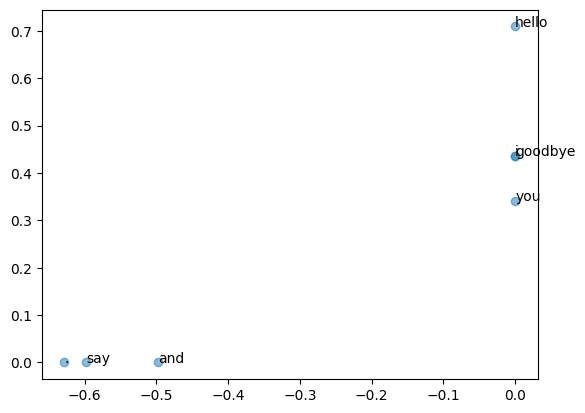

In [ ]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from common.util import preprocess, create_co_matrix, ppmi


text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(id_to_word)
C = create_co_matrix(corpus, vocab_size, window_size=1)
W = ppmi(C)

# SVD
U, S, V = np.linalg.svd(W)

np.set_printoptions(precision=3)  # 유효 자릿수를 세 자리로 표시
print(C[0])
print(W[0])
print(U[0])

# 플롯
for word, word_id in word_to_id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))
plt.scatter(U[:,0], U[:,1], alpha=0.5)
plt.show()


* 희소벡터인 W[0]가 SVD에 의해 밀집벡터 U[0]로 변함
* 2차원 벡터로 줄이려면 처음의 두 원소를 꺼내면 됨

In [ ]:
print(U[0, :2])

[-1.110e-16  3.409e-01]


* 행렬의 크기가 N이면 SVD 계산은 $O(N^3)$ 이 걸림  
    => Truncated SVD같은 더 빠른 기법을 이용  
    * 특잇값이 작은 것은 버리는 방식으로 성능 향상
    * scikit-learn 라이브러리의 Truncated SVD 이용

#### PTB 데이터셋
* 펜 트리뱅크(PTB)
* PTB 말뭉치는 텍스트 파일로 제공, PTB 문장에 몇 가지 전처리가 되어있음
    * 희소한 단어를 \<unk\>라는 특수 문자로 치환
    * 구체적인 숫자를 N으로 대체
    * 한 문장이 하나의 줄로 저장
    * 각 문장의 끝에 \<eos\>라는 특수문자를 삽입


In [ ]:
import sys
sys.path.append('..')
from dataset import ptb


corpus, word_to_id, id_to_word = ptb.load_data('train')

print('말뭉치 크기:', len(corpus))
print('corpus[:30]:', corpus[:30])
print()
print('id_to_word[0]:', id_to_word[0])
print('id_to_word[1]:', id_to_word[1])
print('id_to_word[2]:', id_to_word[2])
print()
print("word_to_id['car']:", word_to_id['car'])
print("word_to_id['happy']:", word_to_id['happy'])
print("word_to_id['lexus']:", word_to_id['lexus'])


Done
말뭉치 크기: 929589
corpus[:30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

id_to_word[0]: aer
id_to_word[1]: banknote
id_to_word[2]: berlitz

word_to_id['car']: 3856
word_to_id['happy']: 4428
word_to_id['lexus']: 7426


#### PTB 데이터셋 평가
* PTB 데이터셋에 통계 기반 기법을 적용

In [4]:
import sys
sys.path.append('..')
import numpy as np
from common.util import most_similar, create_co_matrix, ppmi
from dataset import ptb


window_size = 2
wordvec_size = 100

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
print('동시발생 수 계산 ...')
C = create_co_matrix(corpus, vocab_size, window_size)
print('PPMI 계산 ...')
W = ppmi(C, verbose=True)

print('calculating SVD ...')
try:
    # truncated SVD (빠르다!)
    from sklearn.utils.extmath import randomized_svd
    U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5,
                             random_state=None)
except ImportError:
    # SVD (느리다)
    U, S, V = np.linalg.svd(W)

word_vecs = U[:, :wordvec_size]

querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


동시발생 수 계산 ...
PPMI 계산 ...
1.0% 완료
2.0% 완료
3.0% 완료
4.0% 완료
5.0% 완료
6.0% 완료
7.0% 완료
8.0% 완료
9.0% 완료
10.0% 완료
11.0% 완료
12.0% 완료
13.0% 완료
14.0% 완료
15.0% 완료
16.0% 완료
17.0% 완료
18.0% 완료
19.0% 완료
20.0% 완료
21.0% 완료
22.0% 완료
23.0% 완료
24.0% 완료
25.0% 완료
26.0% 완료
27.0% 완료
28.0% 완료
29.0% 완료
30.0% 완료
31.0% 완료
32.0% 완료
33.0% 완료
34.0% 완료
35.0% 완료
36.0% 완료
37.0% 완료
38.0% 완료
39.0% 완료
40.0% 완료
41.0% 완료
42.0% 완료
43.0% 완료
44.0% 완료
45.0% 완료
46.0% 완료
47.0% 완료
48.0% 완료
49.0% 완료
50.0% 완료
51.0% 완료
52.0% 완료
53.0% 완료
54.0% 완료
55.0% 완료
56.0% 완료
57.0% 완료
58.0% 완료
59.0% 완료
60.0% 완료
61.0% 완료
62.0% 완료
63.0% 완료
64.0% 완료
65.0% 완료
66.0% 완료
67.0% 완료
68.0% 완료
69.0% 완료
70.0% 완료
71.0% 완료
72.0% 완료
73.0% 완료
74.0% 완료
75.0% 완료
76.0% 완료
77.0% 완료
78.0% 완료
79.0% 완료
80.0% 완료
81.0% 완료
82.0% 완료
83.0% 완료
84.0% 완료
85.0% 완료
86.0% 완료
87.0% 완료
88.0% 완료
89.0% 완료
90.0% 완료
91.0% 완료
92.0% 완료
93.0% 완료
94.0% 완료
95.0% 완료
96.0% 완료
97.0% 완료
98.0% 완료
99.0% 완료
100.0% 완료
calculating SVD ...

[query] you
 i: 0.6680405139923096
 we: 0.6004825830459595
 a

* 단어의 의미 혹은 문법적인 관점에서 비슷한 단어들이 가까운 벡터로 나타남